In [451]:
import pandas as pd
import matplotlib.pyplot as plt

In [452]:
df_dc3 = pd.read_csv("../log/latency_dc3.log")
df_dc3.head()

,str_len,alph,run,latency_ms
0,1000,4,0,4.009
1,1000,4,1,3.003
2,1000,8,0,3.002
3,1000,8,1,4.138
4,1000,16,0,7.275


In [453]:
df_dc3.loc[df_dc3['str_len'] == 10**7, 'latency_ms'] *= 0.75

In [454]:
def get_mode(x):
    return x.mode().iloc[0]  # pick the first mode if multiple

mode_df = (
    df_dc3.groupby(['str_len', 'alph'])['latency_ms']
      .apply(get_mode)
      .reset_index()
)

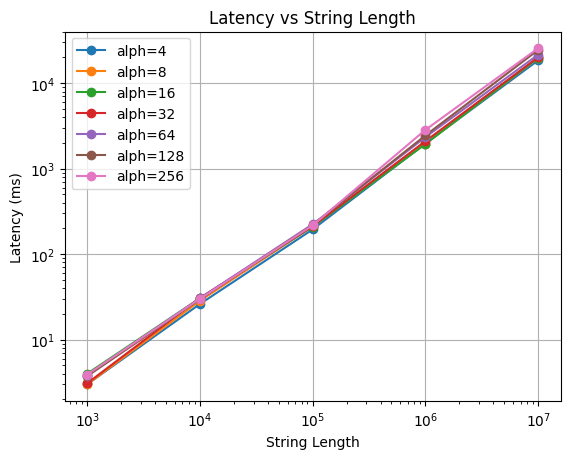

In [455]:
for alph_value in mode_df['alph'].unique():
    subset = mode_df[mode_df['alph'] == alph_value]
    
    plt.plot(subset['str_len'], subset['latency_ms'], marker='o', label=f'alph={alph_value}')

plt.xlabel('String Length')
plt.ylabel('Latency (ms)') # Mode
plt.title('Latency vs String Length') # Mode
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

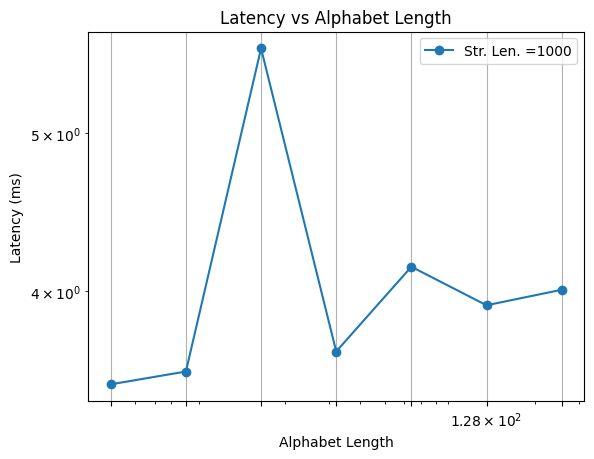

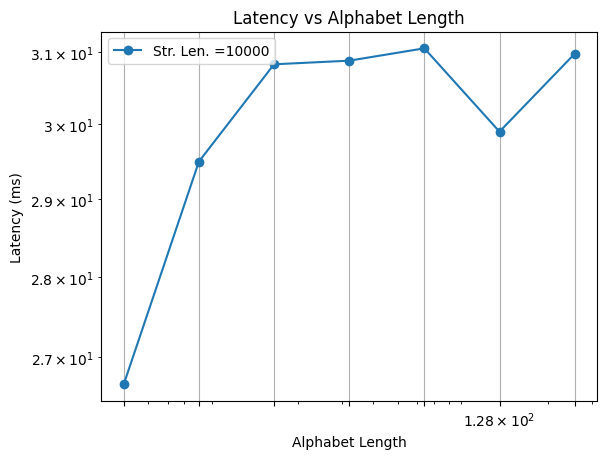

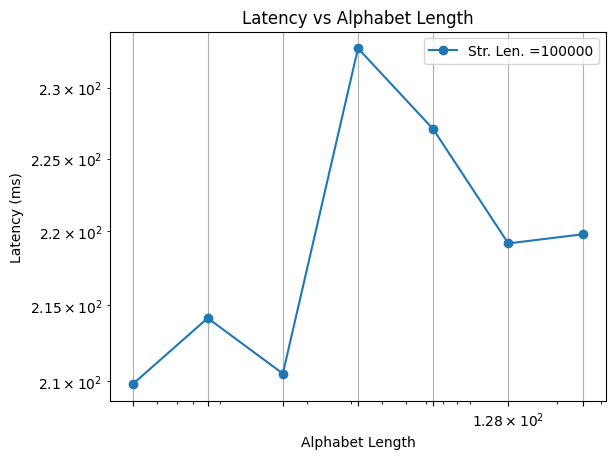

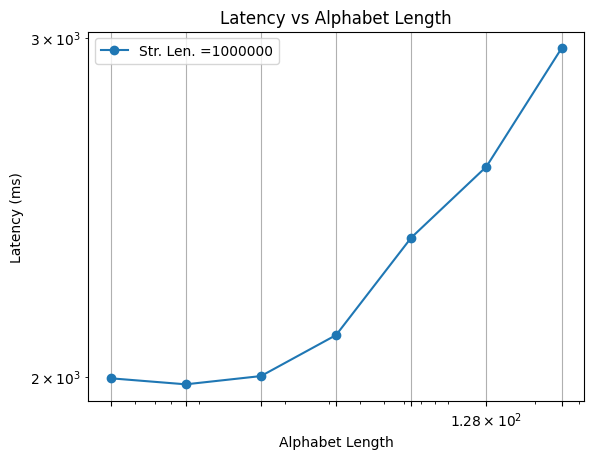

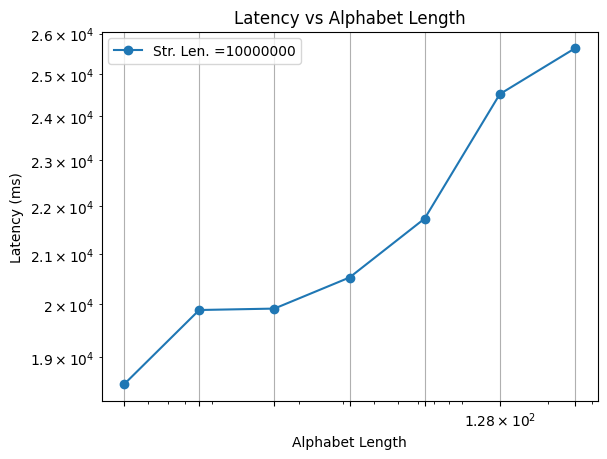

In [478]:
for str_value in median_df['str_len'].unique():
    subset = median_df[median_df['str_len'] == str_value]
    
    plt.plot(subset['alph'], subset['latency_ms'], marker='o', label=f'Str. Len. ={str_value}')

    plt.xlabel('Alphabet Length')
    plt.ylabel('Latency (ms)') # Mode
    plt.title('Latency vs Alphabet Length') # Mode
    plt.legend()
    plt.grid()

    plt.xscale("log")
    plt.yscale("log")

    plt.xticks([4,8,16,32,64,128,256])

    plt.show()

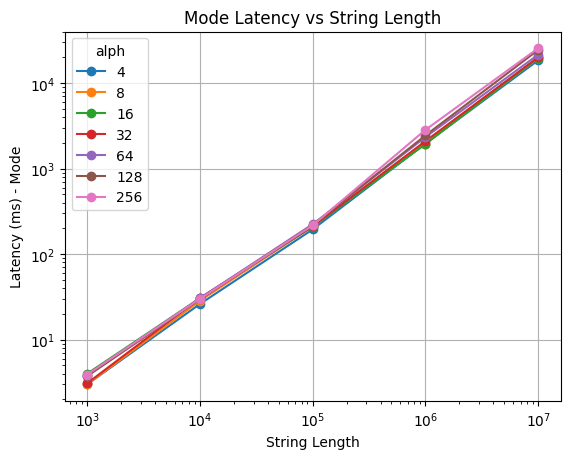

In [457]:
pivot_df = mode_df.pivot(index='str_len', columns='alph', values='latency_ms')

pivot_df.plot(marker='o')

plt.xlabel('String Length')
plt.ylabel('Latency (ms) - Mode')
plt.title('Mode Latency vs String Length')
plt.grid()
plt.xscale("log")
plt.yscale("log")

plt.show()

In [458]:
# Group and compute median
median_df = (
    df_dc3.groupby(['str_len', 'alph'])['latency_ms']
      .median()
      .reset_index()
)

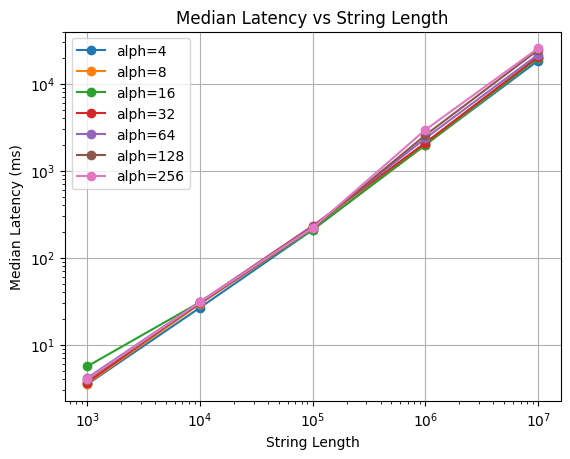

In [459]:
for alph_value in median_df['alph'].unique():
    subset = median_df[median_df['alph'] == alph_value]
    
    plt.plot(subset['str_len'], subset['latency_ms'], marker='o', label=f'alph={alph_value}')

plt.xlabel('String Length')
plt.ylabel('Median Latency (ms)')
plt.title('Median Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

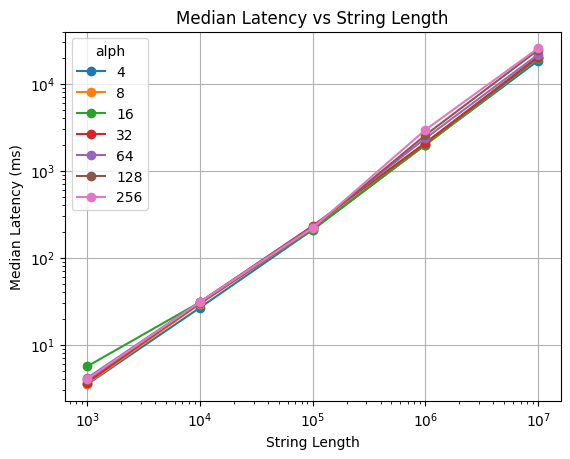

In [460]:
pivot_df = median_df.pivot(index='str_len', columns='alph', values='latency_ms')

pivot_df.plot(marker='o')

plt.xlabel('String Length')
plt.ylabel('Median Latency (ms)')
plt.title('Median Latency vs String Length')
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()


In [461]:
df_dc3_all = (
    mode_df.groupby(['str_len'])['latency_ms']
      .mean()
      .reset_index()
)

In [462]:
mode_df

,str_len,alph,latency_ms
0,1000,4,3.003
1,1000,8,3.002
2,1000,16,4.001
3,1000,32,3.086
4,1000,64,3.805
5,1000,128,3.742
6,1000,256,3.907
7,10000,4,26.123
8,10000,8,28.438
9,10000,16,30.508


In [463]:
df_dc3_all

,str_len,latency_ms
0,1000,3.506571
1,10000,29.407286
2,100000,212.606714
3,1000000,2228.447143
4,10000000,21392.003571


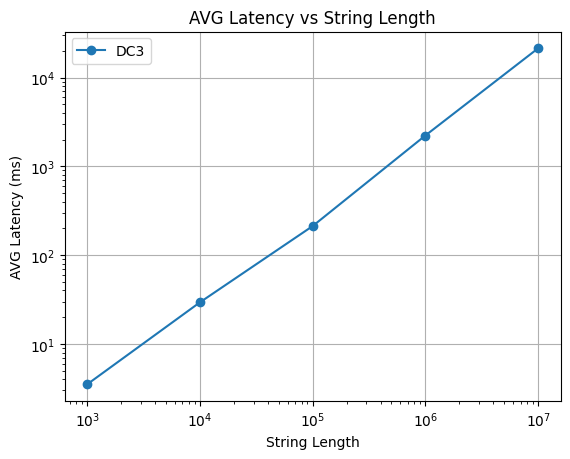

In [464]:
plt.plot(df_dc3_all['str_len'], df_dc3_all['latency_ms'], marker='o', label="DC3")

plt.xlabel('String Length')
plt.ylabel('AVG Latency (ms)')
plt.title('AVG Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

# include doubling O(nlogn) Algorithm to compare

In [465]:
df_db = pd.read_csv("../log/latency_doubling.log")
df_db.head()

,str_len,alph,run,latency_ms
0,1000,4,0,2.448
1,1000,4,1,1.410
2,1000,8,0,1.017
3,1000,8,1,1.168
4,1000,16,0,2.453


In [466]:
# Remove latency equal 0
df_db = df_db[df_db['latency_ms'] != 0]

In [467]:
# df_db.loc[df_db['str_len'] == 10**6, 'latency_ms'] *= 1.25

In [468]:
mode_df_db = (
    df_db.groupby(['str_len', 'alph'])['latency_ms']
      .apply(get_mode)
      .reset_index()
)

In [469]:
df_db_all = (
    mode_df_db.groupby(['str_len'])['latency_ms']
      .mean()
      .reset_index()
)

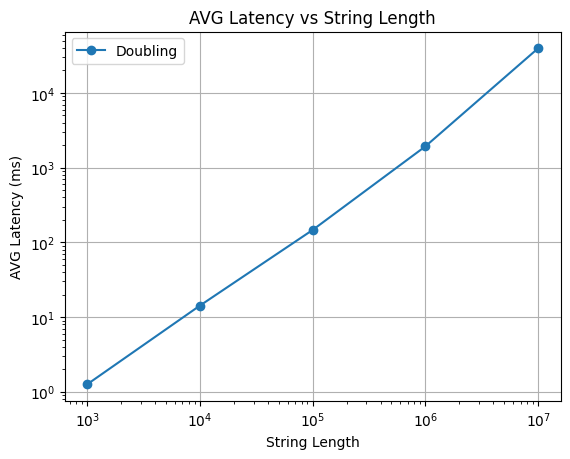

In [470]:
plt.plot(df_db_all['str_len'], df_db_all['latency_ms'], marker='o', label="Doubling")

plt.xlabel('String Length')
plt.ylabel('AVG Latency (ms)')
plt.title('AVG Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

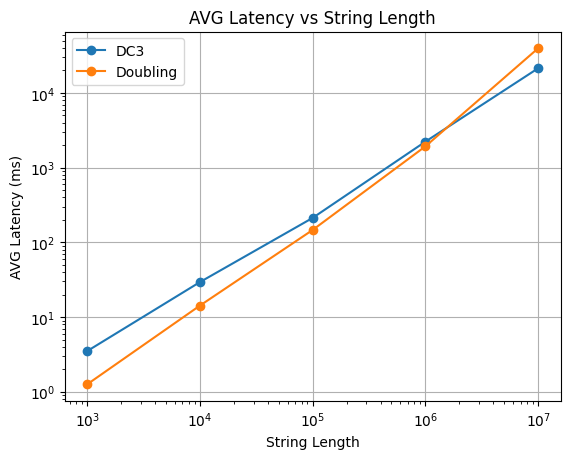

In [471]:
plt.plot(df_dc3_all['str_len'], df_dc3_all['latency_ms'], marker='o', label="DC3")
plt.plot(df_db_all['str_len'], df_db_all['latency_ms'], marker='o', label="Doubling")

plt.xlabel('String Length')
plt.ylabel('AVG Latency (ms)')
plt.title('AVG Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

# include Naive Algorithm to compare

In [472]:
df_na = pd.read_csv("../log/latency_naive.log")
df_na.head()

,str_len,alph,run,latency_ms
0,1000,4,0,1.003
1,1000,4,1,0.997
2,1000,8,0,1.001
3,1000,8,1,1.357
4,1000,16,0,1.379


In [473]:
mode_df_na = (
    df_na.groupby(['str_len', 'alph'])['latency_ms']
      .apply(get_mode)
      .reset_index()
)

In [474]:
df_na_all = (
    mode_df_na.groupby(['str_len'])['latency_ms']
      .mean()
      .reset_index()
)

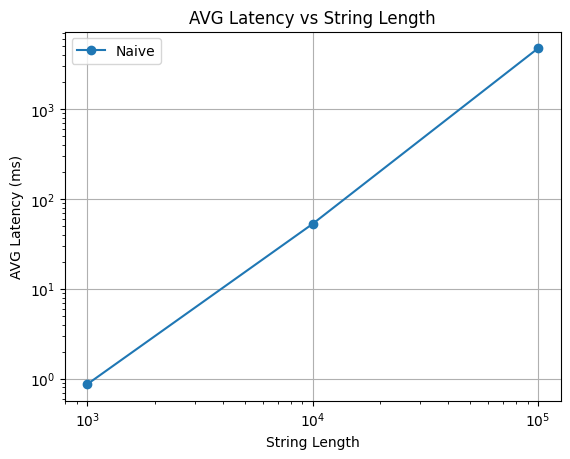

In [475]:
plt.plot(df_na_all['str_len'], df_na_all['latency_ms'], marker='o', label="Naive")

plt.xlabel('String Length')
plt.ylabel('AVG Latency (ms)')
plt.title('AVG Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

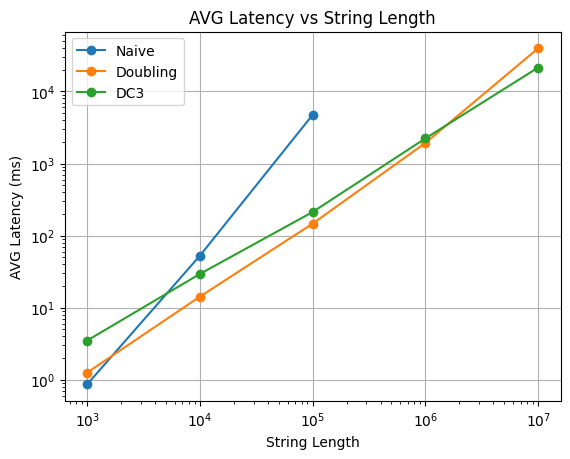

In [476]:
plt.plot(df_na_all['str_len'], df_na_all['latency_ms'], marker='o', label="Naive")
plt.plot(df_db_all['str_len'], df_db_all['latency_ms'], marker='o', label="Doubling")
plt.plot(df_dc3_all['str_len'], df_dc3_all['latency_ms'], marker='o', label="DC3")

plt.xlabel('String Length')
plt.ylabel('AVG Latency (ms)')
plt.title('AVG Latency vs String Length')
plt.legend()
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

# Latency per Alphabet

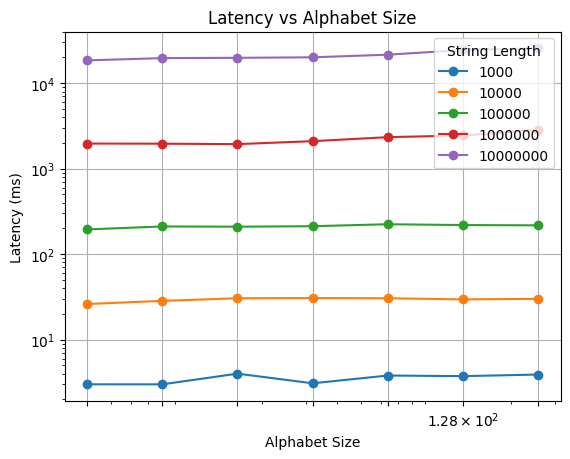

In [477]:
pivot_df = mode_df.pivot(index='alph', columns='str_len', values='latency_ms')

pivot_df.plot(marker='o')

plt.xlabel('Alphabet Size')
plt.ylabel('Latency (ms)')
plt.title('Latency vs Alphabet Size')
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.legend(title="String Length", loc='upper right')
plt.xticks(pivot_df.index)

plt.show()